# Notebook 02 - Model Selection

Comparison of ...
1. simple_fcn: simple Fully-Convolutional-Network-Baseline.
2. residual_cnn: 1D-CNN with Residual Connections.
3. tiny_residual_tcn: compact Temporal-Convolutional-Network with Dilated Convolutions.
4. inception_lite: small Multi-Scale-CNN following the InceptionTime-idea.
5. small_gru: small recurrent Network.

Decision is based on validation-segment-RMSE, model stability, number of parameters, and learning curve

## 1. Setup

In [1]:
# Core imports
import os
import re
import gc
import json
import time
import random
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Disable XLA/JIT to avoid long graph compilation during repeated fold training.
tf.config.optimizer.set_jit(False)

# Let TensorFlow allocate GPU memory gradually.
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("XLA/JIT enabled:", tf.config.optimizer.get_jit())

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
XLA/JIT enabled: 


## 2. Configuration

In [4]:
# Experiment setup
WINDOW_SIZE = 30
STEP_SIZE = 10
TARGET_COLUMN = "Energy expenditures (W/kg)"
TIME_COLUMN = "Time (s)"
ACTIVITY_COLUMN = "Activity Code"
SUBJECT_COLUMN = "Subject"
WKG_TO_KCAL_PER_MIN = 60 / 4184

SUBJECT_WEIGHTS_KG = {
    1: 63.49,
    2: 63.49,
    3: 71.20,
    4: 68.03,
    5: 68.03,
    6: 68.03,
    7: 95.24,
    8: 65.76,
    9: 68.93,
    10: 58.05,
}

INPUT_SIGNALS = [
    "Waist Acceleration",
    "Chest Acceleration",
    "Left Ankle Acceleration",
    "right Ankle Acceleration",
    "left wrist Acceleration",
    "right wrist Acceleration",
    "EMG_magnitude_left",
    "EMG_magnitude_right",
    "left wrist electrodermal",
    "right wrist electrodermal",
    "left wrist Temperature",
    "right wrist Temperature",
    "Breath Frequency",
    "Minute Ventilation",
    "SpO2",
    "Heart Rate",
]

MANUAL_DATA_DIR = None

OUTPUT_DIR = Path("/kaggle/working/notebook_02_model_selection")
if not Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("notebook_02_model_selection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Number of input signals:", len(INPUT_SIGNALS))
print("Output directory:", OUTPUT_DIR)

Number of input signals: 16
Output directory: /kaggle/working/notebook_02_model_selection


## 3. Load and Prepare Data

In [ ]:
def parse_subject_id(path):
    """Extract the subject id from filenames such as Subject (3).csv."""
    match = re.search(r"Subject \((\d+)\)", path.name)
    if match is None:
        raise ValueError(f"Could not parse subject id from {path.name}")
    return int(match.group(1))


def find_data_dir():
    """Find the folder containing the subject CSV files."""
    candidates = []
    if MANUAL_DATA_DIR is not None:
        candidates.append(Path(MANUAL_DATA_DIR))

    candidates.extend([
        Path("/kaggle/input"),
        Path("/kaggle/input/data-20260607"),
        Path("/kaggle/input/projekt-2"),
        Path("/kaggle/input/projekt2"),
        Path("Data-20260607"),
        Path("Projekt 2/Data-20260607"),
    ])

    for candidate in candidates:
        if not candidate.exists():
            continue

        direct_matches = sorted(candidate.glob("Subject (*.csv"))
        if direct_matches:
            return candidate

        recursive_matches = sorted(candidate.rglob("Subject (*.csv"))
        if recursive_matches:
            return recursive_matches[0].parent

    raise FileNotFoundError("Could not find Subject CSV files. Set MANUAL_DATA_DIR manually.")


def load_dataset(data_dir):
    """Load all subject CSV files while preserving the original trial order inside each file."""
    frames = []
    files = sorted(data_dir.glob("Subject (*.csv"), key=parse_subject_id)

    for file_path in files:
        subject_id = parse_subject_id(file_path)
        frame = pd.read_csv(file_path)
        frame.columns = [column.strip() for column in frame.columns]

        # Preserve the original row order from the CSV file.
        # This is crucial: sorting by time would interleave different activities that share similar time stamps.
        frame["Original_Row_Order"] = np.arange(len(frame))
        frame[SUBJECT_COLUMN] = subject_id
        frame["Weight_kg"] = SUBJECT_WEIGHTS_KG[subject_id]
        frame["Target_kcal_min"] = frame[TARGET_COLUMN] * frame["Weight_kg"] * WKG_TO_KCAL_PER_MIN
        frames.append(frame)

    data = pd.concat(frames, ignore_index=True)
    data = data.sort_values([SUBJECT_COLUMN, "Original_Row_Order"]).reset_index(drop=True)
    return data


def validate_columns(data):
    """Check that all required columns exist."""
    required = [TIME_COLUMN, SUBJECT_COLUMN, ACTIVITY_COLUMN, TARGET_COLUMN] + INPUT_SIGNALS
    missing = [column for column in required if column not in data.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")


def add_segment_ids(data):
    data = data.sort_values([SUBJECT_COLUMN, "Original_Row_Order"]).reset_index(drop=True).copy()

    previous_subject = data[SUBJECT_COLUMN].shift(1)
    previous_activity = data[ACTIVITY_COLUMN].shift(1)
    previous_time = data[TIME_COLUMN].shift(1)

    subject_changed = data[SUBJECT_COLUMN] != previous_subject
    activity_changed = data[ACTIVITY_COLUMN] != previous_activity

    time_difference = data[TIME_COLUMN] - previous_time
    time_not_continuous = (time_difference < 0) | (time_difference > 1.5)
    time_not_continuous = time_not_continuous.fillna(True)

    new_segment = subject_changed | activity_changed | time_not_continuous
    data["Segment ID"] = new_segment.cumsum().astype(int)
    return data


def build_segment_summary(data):
    """Build one summary row per segment."""
    summary = (
        data.groupby("Segment ID")
        .agg(
            Subject=(SUBJECT_COLUMN, "first"),
            Activity_Code=(ACTIVITY_COLUMN, "first"),
            Number_of_Rows=(TIME_COLUMN, "size"),
            Number_of_Targets=(TARGET_COLUMN, "nunique"),
            Start_Time=(TIME_COLUMN, "min"),
            End_Time=(TIME_COLUMN, "max"),
            Target_W_kg=(TARGET_COLUMN, "first"),
            Weight_kg=("Weight_kg", "first"),
            Target_kcal_min=("Target_kcal_min", "first"),
        )
        .reset_index()
    )

    missing_counts = data.groupby("Segment ID")[INPUT_SIGNALS].apply(lambda frame: int(frame.isna().sum().sum()))
    summary["Missing_Input_Values"] = summary["Segment ID"].map(missing_counts)
    return summary


def create_windows(data, input_signals, window_size=30, step_size=10):
    """Create overlapping windows inside each segment."""
    windows = []
    rows = []
    window_id = 0

    for segment_id, segment in data.groupby("Segment ID", sort=True):
        segment = segment.sort_values("Original_Row_Order").reset_index(drop=True)
        if len(segment) < window_size:
            continue

        for start_index in range(0, len(segment) - window_size + 1, step_size):
            end_index = start_index + window_size
            window = segment.loc[start_index:end_index - 1, input_signals].to_numpy(dtype=np.float32)
            windows.append(window)
            rows.append({
                "Window ID": window_id,
                "Segment ID": int(segment_id),
                "Subject": int(segment[SUBJECT_COLUMN].iloc[0]),
                "Activity Code": int(segment[ACTIVITY_COLUMN].iloc[0]),
                "Start Index": int(start_index),
                "End Index": int(end_index),
                "Target_W_kg": float(segment[TARGET_COLUMN].iloc[0]),
                "Weight_kg": float(segment["Weight_kg"].iloc[0]),
                "Target_kcal_min": float(segment["Target_kcal_min"].iloc[0]),
            })
            window_id += 1

    X = np.stack(windows).astype(np.float32)
    metadata = pd.DataFrame(rows)
    y_wkg = metadata["Target_W_kg"].to_numpy(dtype=np.float32)
    return X, y_wkg, metadata


DATA_DIR = find_data_dir()
print("Data directory:", DATA_DIR)

raw_data = load_dataset(DATA_DIR)
validate_columns(raw_data)
data = add_segment_ids(raw_data)
segment_summary = build_segment_summary(data)

if not (segment_summary["Number_of_Targets"] == 1).all():
    raise ValueError("At least one segment has more than one target value.")

X_raw, y_wkg, metadata = create_windows(data, INPUT_SIGNALS, WINDOW_SIZE, STEP_SIZE)

print("Dataset shape:", data.shape)
print("Number of segments:", data["Segment ID"].nunique())
print("Window shape:", X_raw.shape)
display(segment_summary["Number_of_Rows"].describe())
display(metadata.head())

# Hard sanity checks from Notebook 01/02. Stop immediately if segmentation is wrong.
assert data["Segment ID"].nunique() == 198, "Expected 198 continuous segments/trials."
assert X_raw.shape[0] == 6724, "Expected 6,724 windows with window size 30 and step size 10."


## 4. LOSO Splits and Normalization

In [6]:
def create_loso_splits(subjects):
    """Create deterministic LOSO splits: one test subject and the next subject as validation."""
    subjects = list(sorted(subjects))
    splits = []
    for fold_index, test_subject in enumerate(subjects):
        validation_subject = subjects[(fold_index + 1) % len(subjects)]
        train_subjects = [subject for subject in subjects if subject not in [test_subject, validation_subject]]
        splits.append({
            "Fold": fold_index + 1,
            "Train Subjects": train_subjects,
            "Validation Subject": validation_subject,
            "Test Subject": test_subject,
        })
    return splits


def get_split_indices(metadata, split):
    """Return train, validation, and test indices for one split."""
    train_mask = metadata["Subject"].isin(split["Train Subjects"]).to_numpy()
    validation_mask = (metadata["Subject"] == split["Validation Subject"]).to_numpy()
    test_mask = (metadata["Subject"] == split["Test Subject"]).to_numpy()
    return np.where(train_mask)[0], np.where(validation_mask)[0], np.where(test_mask)[0]


def normalize_by_training_data(X_train, X_validation, X_test):
    """Standardize channels using training data only."""
    mean = np.nanmean(X_train, axis=(0, 1), keepdims=True)
    std = np.nanstd(X_train, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)

    X_train = (X_train - mean) / std
    X_validation = (X_validation - mean) / std
    X_test = (X_test - mean) / std

    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    X_validation = np.nan_to_num(X_validation, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X_train, X_validation, X_test


subjects = sorted(metadata["Subject"].unique())
loso_splits = create_loso_splits(subjects)
display(pd.DataFrame(loso_splits))

for split in loso_splits:
    train_idx, validation_idx, test_idx = get_split_indices(metadata, split)
    assert set(metadata.iloc[train_idx]["Subject"]).isdisjoint(set(metadata.iloc[validation_idx]["Subject"]))
    assert set(metadata.iloc[train_idx]["Subject"]).isdisjoint(set(metadata.iloc[test_idx]["Subject"]))
    assert set(metadata.iloc[validation_idx]["Subject"]).isdisjoint(set(metadata.iloc[test_idx]["Subject"]))

print("All LOSO splits passed leakage validation.")

,Fold,Train Subjects,Validation Subject,Test Subject
0,1,"[3, 4, 5, 6, 7, 8, 9, 10]",2,1
1,2,"[1, 4, 5, 6, 7, 8, 9, 10]",3,2
2,3,"[1, 2, 5, 6, 7, 8, 9, 10]",4,3
3,4,"[1, 2, 3, 6, 7, 8, 9, 10]",5,4
4,5,"[1, 2, 3, 4, 7, 8, 9, 10]",6,5
5,6,"[1, 2, 3, 4, 5, 8, 9, 10]",7,6
6,7,"[1, 2, 3, 4, 5, 6, 9, 10]",8,7
7,8,"[1, 2, 3, 4, 5, 6, 7, 10]",9,8
8,9,"[1, 2, 3, 4, 5, 6, 7, 8]",10,9
9,10,"[2, 3, 4, 5, 6, 7, 8, 9]",1,10


All LOSO splits passed leakage validation.


## 5. Metrics

In [7]:
def rmse(y_true, y_pred):
    """Compute root mean squared error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred, prefix):
    """Compute regression metrics with a prefix."""
    return {
        f"{prefix}_RMSE_W_kg": rmse(y_true, y_pred),
        f"{prefix}_MAE_W_kg": float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_R2_W_kg": float(r2_score(y_true, y_pred)),
    }


def aggregate_to_segments(prediction_frame):
    """Average window predictions per segment."""
    segment_predictions = (
        prediction_frame.groupby(["Segment ID", "Subject", "Activity Code"], as_index=False)
        .agg(
            Actual_W_kg=("Actual_W_kg", "first"),
            Predicted_W_kg=("Predicted_W_kg", "mean"),
            Weight_kg=("Weight_kg", "first"),
        )
    )
    segment_predictions["Actual_kcal_min"] = segment_predictions["Actual_W_kg"] * segment_predictions["Weight_kg"] * WKG_TO_KCAL_PER_MIN
    segment_predictions["Predicted_kcal_min"] = segment_predictions["Predicted_W_kg"] * segment_predictions["Weight_kg"] * WKG_TO_KCAL_PER_MIN
    return segment_predictions


def evaluate_predictions(metadata_subset, y_true, y_pred, prefix):
    """Evaluate predictions on window and segment level."""
    frame = metadata_subset.copy().reset_index(drop=True)
    frame["Actual_W_kg"] = y_true
    frame["Predicted_W_kg"] = y_pred
    segments = aggregate_to_segments(frame)

    metrics = {}
    metrics.update(regression_metrics(y_true, y_pred, f"{prefix}_Window"))
    metrics.update(regression_metrics(segments["Actual_W_kg"], segments["Predicted_W_kg"], f"{prefix}_Segment"))
    return metrics, frame, segments

## 6. Five Models

In [8]:
def compile_regression_model(model, learning_rate=1e-3):
    """Compile a Keras regression model."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae"), keras.metrics.RootMeanSquaredError(name="rmse")],
        jit_compile=False,
    )
    return model


def build_simple_fcn(input_shape, filters=32, kernel_size=5, learning_rate=1e-3):
    """Build a simple FCN-style 1D CNN baseline."""
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    return compile_regression_model(keras.Model(inputs, outputs, name="simple_fcn"), learning_rate)


def residual_cnn_block(x, filters, kernel_size, dropout):
    """Build one residual CNN block."""
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)
    x = layers.Add()([shortcut, x])
    return layers.Activation("relu")(x)


def build_residual_cnn(input_shape, filters=32, kernel_size=5, dropout=0.10, learning_rate=1e-3):
    """Build a compact residual CNN."""
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="relu")(inputs)
    x = residual_cnn_block(x, filters, kernel_size, dropout)
    x = residual_cnn_block(x, filters, kernel_size, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)
    return compile_regression_model(keras.Model(inputs, outputs, name="residual_cnn"), learning_rate)


def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout):
    """Build one residual TCN block with dilated convolutions."""
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)
    x = layers.Add()([shortcut, x])
    return layers.Activation("relu")(x)


def build_tiny_residual_tcn(input_shape, filters=32, kernel_size=3, dropout=0.10, learning_rate=1e-3):
    """Build a compact residual TCN."""
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for dilation_rate in [1, 2, 4]:
        x = tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)
    return compile_regression_model(keras.Model(inputs, outputs, name="tiny_residual_tcn"), learning_rate)


def inception_lite_block(x, filters, dropout):
    """Build one lightweight Inception-style temporal block."""
    branch_3 = layers.Conv1D(filters, 3, padding="same", activation="relu")(x)
    branch_5 = layers.Conv1D(filters, 5, padding="same", activation="relu")(x)
    branch_9 = layers.Conv1D(filters, 9, padding="same", activation="relu")(x)
    pooled = layers.MaxPooling1D(pool_size=3, strides=1, padding="same")(x)
    branch_pool = layers.Conv1D(filters, 1, padding="same", activation="relu")(pooled)
    x = layers.Concatenate()([branch_3, branch_5, branch_9, branch_pool])
    x = layers.BatchNormalization()(x)
    return layers.Dropout(dropout)(x)


def build_inception_lite(input_shape, filters=16, dropout=0.10, learning_rate=1e-3):
    """Build a small InceptionTime-inspired model."""
    inputs = keras.Input(shape=input_shape)
    x = inception_lite_block(inputs, filters, dropout)
    x = inception_lite_block(x, filters, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)
    return compile_regression_model(keras.Model(inputs, outputs, name="inception_lite"), learning_rate)


def build_small_gru(input_shape, units=32, dropout=0.10, learning_rate=1e-3):
    """Build a small recurrent comparison model."""
    inputs = keras.Input(shape=input_shape)
    x = layers.GRU(units, dropout=dropout, recurrent_dropout=0.0)(inputs)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)
    return compile_regression_model(keras.Model(inputs, outputs, name="small_gru"), learning_rate)


def build_model_from_config(config, input_shape):
    """Build a model from a configuration dictionary."""
    name = config["name"]
    params = config["params"]
    if name == "simple_fcn":
        return build_simple_fcn(input_shape, **params)
    if name == "residual_cnn":
        return build_residual_cnn(input_shape, **params)
    if name == "tiny_residual_tcn":
        return build_tiny_residual_tcn(input_shape, **params)
    if name == "inception_lite":
        return build_inception_lite(input_shape, **params)
    if name == "small_gru":
        return build_small_gru(input_shape, **params)
    raise ValueError(f"Unknown model: {name}")


MODEL_CONFIGS = [
    {"name": "simple_fcn", "reason": "FCN baseline for raw time-series windows.", "params": {"filters": 32, "kernel_size": 5, "learning_rate": 1e-3}},
    {"name": "residual_cnn", "reason": "Residual CNN tests whether skip connections improve stable feature learning.", "params": {"filters": 32, "kernel_size": 5, "dropout": 0.10, "learning_rate": 1e-3}},
    {"name": "tiny_residual_tcn", "reason": "TCN uses residual blocks and dilated convolutions for temporal context.", "params": {"filters": 32, "kernel_size": 3, "dropout": 0.10, "learning_rate": 1e-3}},
    {"name": "inception_lite", "reason": "Multi-scale kernels capture temporal patterns at different durations.", "params": {"filters": 16, "dropout": 0.10, "learning_rate": 1e-3}},
    {"name": "small_gru", "reason": "Small recurrent comparison model.", "params": {"units": 32, "dropout": 0.10, "learning_rate": 1e-3}},
]

display(pd.DataFrame([{"Model": c["name"], "Reason": c["reason"], "Params": json.dumps(c["params"])} for c in MODEL_CONFIGS]))

,Model,Reason,Params
0,simple_fcn,FCN baseline for raw time-series windows.,"{""filters"": 32, ""kernel_size"": 5, ""learning_ra..."
1,residual_cnn,Residual CNN tests whether skip connections im...,"{""filters"": 32, ""kernel_size"": 5, ""dropout"": 0..."
2,tiny_residual_tcn,TCN uses residual blocks and dilated convoluti...,"{""filters"": 32, ""kernel_size"": 3, ""dropout"": 0..."
3,inception_lite,Multi-scale kernels capture temporal patterns ...,"{""filters"": 16, ""dropout"": 0.1, ""learning_rate..."
4,small_gru,Small recurrent comparison model.,"{""units"": 32, ""dropout"": 0.1, ""learning_rate"":..."


## 7. Training and Evaluation Helpers

In [9]:
def predict_in_batches(model, X, batch_size=512):
    """Predict via direct model calls to avoid repeated predict graph compilation."""
    predictions = []
    for start in range(0, len(X), batch_size):
        batch = tf.convert_to_tensor(X[start:start + batch_size], dtype=tf.float32)
        predictions.append(model(batch, training=False).numpy().reshape(-1))
    return np.concatenate(predictions)


def train_one_fold(config, split, max_epochs=100, patience=12, batch_size=64):
    """Train and evaluate one model on one LOSO fold."""
    tf.keras.backend.clear_session()
    gc.collect()

    train_idx, validation_idx, test_idx = get_split_indices(metadata, split)
    X_train, X_validation, X_test = normalize_by_training_data(
        X_raw[train_idx], X_raw[validation_idx], X_raw[test_idx]
    )
    y_train = y_wkg[train_idx]
    y_validation = y_wkg[validation_idx]
    y_test = y_wkg[test_idx]

    model = build_model_from_config(config, input_shape=X_raw.shape[1:])
    parameter_count = int(model.count_params())

    callbacks = [keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        min_delta=1e-4,
    )]

    start_time = time.time()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_validation, y_validation),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )
    training_time = time.time() - start_time

    validation_pred = predict_in_batches(model, X_validation)
    test_pred = predict_in_batches(model, X_test)

    validation_metrics, validation_windows, validation_segments = evaluate_predictions(
        metadata.iloc[validation_idx], y_validation, validation_pred, "Validation"
    )
    test_metrics, test_windows, test_segments = evaluate_predictions(
        metadata.iloc[test_idx], y_test, test_pred, "Test"
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    result = {
        "Model": config["name"],
        "Fold": split["Fold"],
        "Validation Subject": split["Validation Subject"],
        "Test Subject": split["Test Subject"],
        "Best Epoch": best_epoch,
        "Trained Epochs": len(history.history["loss"]),
        "Training Time Seconds": training_time,
        "Number of Parameters": parameter_count,
    }
    result.update(validation_metrics)
    result.update(test_metrics)

    history_frame = pd.DataFrame(history.history)
    history_frame["Model"] = config["name"]
    history_frame["Fold"] = split["Fold"]
    history_frame["Epoch"] = np.arange(1, len(history_frame) + 1)

    validation_segments["Model"] = config["name"]
    validation_segments["Fold"] = split["Fold"]
    test_segments["Model"] = config["name"]
    test_segments["Fold"] = split["Fold"]

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return result, history_frame, validation_segments, test_segments

## 8. Run Model Comparison

In [10]:
RUN_FULL_EXPERIMENT = True

selected_splits = loso_splits if RUN_FULL_EXPERIMENT else loso_splits[:2]
selected_configs = MODEL_CONFIGS

all_results = []
all_histories = []
all_validation_segments = []
all_test_segments = []

for config in selected_configs:
    print("=" * 100)
    print("Model:", config["name"])

    for split in selected_splits:
        print(
            f"Training {config['name']} | fold {split['Fold']} | "
            f"validation subject {split['Validation Subject']} | test subject {split['Test Subject']}"
        )

        result, history_frame, validation_segments, test_segments = train_one_fold(
            config=config,
            split=split,
            max_epochs=100,
            patience=12,
            batch_size=64,
        )

        all_results.append(result)
        all_histories.append(history_frame)
        all_validation_segments.append(validation_segments)
        all_test_segments.append(test_segments)

        # Save incrementally after each fold to keep partial results if Kaggle interrupts the run.
        pd.DataFrame(all_results).to_csv(OUTPUT_DIR / "model_selection_fold_results_incremental.csv", index=False)
        pd.concat(all_histories, ignore_index=True).to_csv(OUTPUT_DIR / "model_selection_learning_curves_incremental.csv", index=False)

        print(
            "Validation Segment RMSE:", round(result["Validation_Segment_RMSE_W_kg"], 3),
            "| Test Segment RMSE:", round(result["Test_Segment_RMSE_W_kg"], 3),
            "| Best epoch:", result["Best Epoch"],
        )

results = pd.DataFrame(all_results)
histories = pd.concat(all_histories, ignore_index=True)
validation_segment_predictions = pd.concat(all_validation_segments, ignore_index=True)
test_segment_predictions = pd.concat(all_test_segments, ignore_index=True)

results.to_csv(OUTPUT_DIR / "model_selection_fold_results.csv", index=False)
histories.to_csv(OUTPUT_DIR / "model_selection_learning_curves.csv", index=False)
validation_segment_predictions.to_csv(OUTPUT_DIR / "validation_segment_predictions.csv", index=False)
test_segment_predictions.to_csv(OUTPUT_DIR / "test_segment_predictions.csv", index=False)

display(results.head())

Model: simple_fcn
Training simple_fcn | fold 1 | validation subject 2 | test subject 1


I0000 00:00:1783238174.334733      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783238174.337604      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Validation Segment RMSE: 1.112 | Test Segment RMSE: 1.668 | Best epoch: 14
Training simple_fcn | fold 2 | validation subject 3 | test subject 2
Validation Segment RMSE: 1.163 | Test Segment RMSE: 0.738 | Best epoch: 7
Training simple_fcn | fold 3 | validation subject 4 | test subject 3
Validation Segment RMSE: 0.863 | Test Segment RMSE: 1.406 | Best epoch: 14
Training simple_fcn | fold 4 | validation subject 5 | test subject 4
Validation Segment RMSE: 0.786 | Test Segment RMSE: 0.671 | Best epoch: 14
Training simple_fcn | fold 5 | validation subject 6 | test subject 5
Validation Segment RMSE: 0.981 | Test Segment RMSE: 0.957 | Best epoch: 5
Training simple_fcn | fold 6 | validation subject 7 | test subject 6
Validation Segment RMSE: 1.327 | Test Segment RMSE: 1.367 | Best epoch: 18
Training simple_fcn | fold 7 | validation subject 8 | test subject 7
Validation Segment RMSE: 0.862 | Test Segment RMSE: 1.504 | Best epoch: 4
Training simple_fcn | fold 8 | validation subject 9 | test subje

,Model,Fold,Validation Subject,Test Subject,Best Epoch,Trained Epochs,Training Time Seconds,Number of Parameters,Validation_Window_RMSE_W_kg,Validation_Window_MAE_W_kg,Validation_Window_R2_W_kg,Validation_Segment_RMSE_W_kg,Validation_Segment_MAE_W_kg,Validation_Segment_R2_W_kg,Test_Window_RMSE_W_kg,Test_Window_MAE_W_kg,Test_Window_R2_W_kg,Test_Segment_RMSE_W_kg,Test_Segment_MAE_W_kg,Test_Segment_R2_W_kg
0,simple_fcn,1,2,1,14,26,21.107445,13185,1.173151,0.989151,0.863226,1.111552,0.974552,0.877410,1.709324,1.360352,0.515664,1.668185,1.345970,0.538697
1,simple_fcn,2,3,2,7,19,13.919940,13185,1.230263,0.979480,0.846157,1.162966,0.960578,0.862528,0.837918,0.672025,0.930225,0.737603,0.607976,0.946019
2,simple_fcn,3,4,3,14,26,18.632013,13185,1.010706,0.798032,0.892228,0.863094,0.750033,0.921409,1.493435,1.216136,0.773299,1.406045,1.183964,0.799054
3,simple_fcn,4,5,4,14,26,18.723897,13185,0.939770,0.739312,0.912110,0.785748,0.622871,0.938413,0.940206,0.682349,0.906738,0.670755,0.541318,0.952534
4,simple_fcn,5,6,5,5,17,12.937139,13185,1.036761,0.828116,0.885502,0.981285,0.809074,0.897427,1.095744,0.779493,0.880515,0.956699,0.706088,0.908699


## 9. Ranking

In [11]:
ranking = (
    results.groupby("Model")
    .agg(
        Mean_Validation_Segment_RMSE_W_kg=("Validation_Segment_RMSE_W_kg", "mean"),
        Std_Validation_Segment_RMSE_W_kg=("Validation_Segment_RMSE_W_kg", "std"),
        Mean_Validation_Segment_MAE_W_kg=("Validation_Segment_MAE_W_kg", "mean"),
        Mean_Validation_Segment_R2_W_kg=("Validation_Segment_R2_W_kg", "mean"),
        Mean_Test_Segment_RMSE_W_kg=("Test_Segment_RMSE_W_kg", "mean"),
        Std_Test_Segment_RMSE_W_kg=("Test_Segment_RMSE_W_kg", "std"),
        Mean_Best_Epoch=("Best Epoch", "mean"),
        Mean_Trained_Epochs=("Trained Epochs", "mean"),
        Mean_Training_Time_Seconds=("Training Time Seconds", "mean"),
        Mean_Number_of_Parameters=("Number of Parameters", "mean"),
    )
    .reset_index()
    .sort_values("Mean_Validation_Segment_RMSE_W_kg")
)

ranking.to_csv(OUTPUT_DIR / "model_selection_ranking.csv", index=False)
display(ranking)

,Model,Mean_Validation_Segment_RMSE_W_kg,Std_Validation_Segment_RMSE_W_kg,Mean_Validation_Segment_MAE_W_kg,Mean_Validation_Segment_R2_W_kg,Mean_Test_Segment_RMSE_W_kg,Std_Test_Segment_RMSE_W_kg,Mean_Best_Epoch,Mean_Trained_Epochs,Mean_Training_Time_Seconds,Mean_Number_of_Parameters
3,small_gru,0.946327,0.307903,0.761263,0.867945,1.113735,0.305777,16.1,28.1,18.643040,5889.0
4,tiny_residual_tcn,0.973045,0.304704,0.749326,0.876665,1.198184,0.266537,18.2,30.2,40.609305,19489.0
0,inception_lite,1.012939,0.254506,0.793192,0.862783,1.149335,0.270002,18.8,30.8,32.198028,25793.0
1,residual_cnn,1.018115,0.273252,0.812500,0.867843,1.277888,0.539451,5.3,17.3,19.646799,24801.0
2,simple_fcn,1.034037,0.177077,0.842405,0.867289,1.199314,0.325709,9.9,21.9,16.276495,13185.0


## 10. Validation Performance Plots

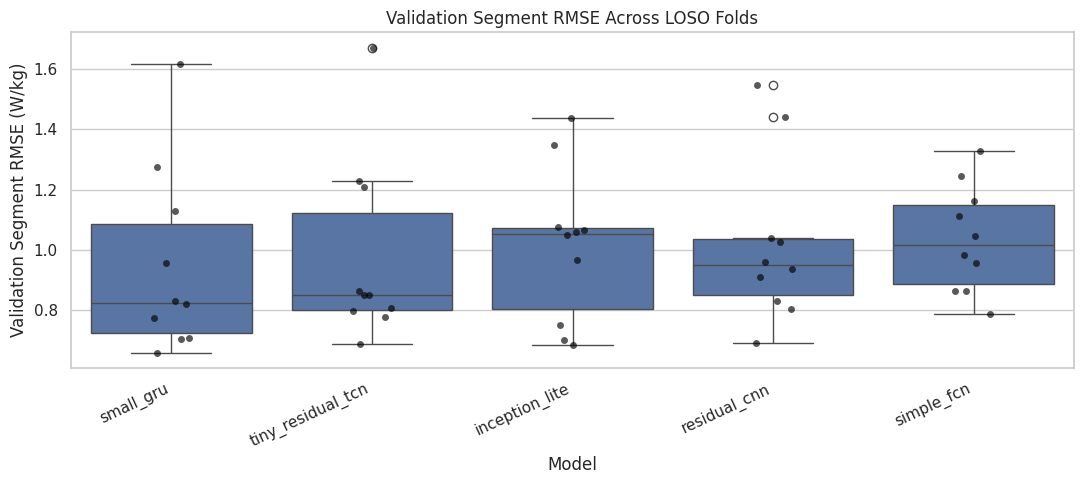

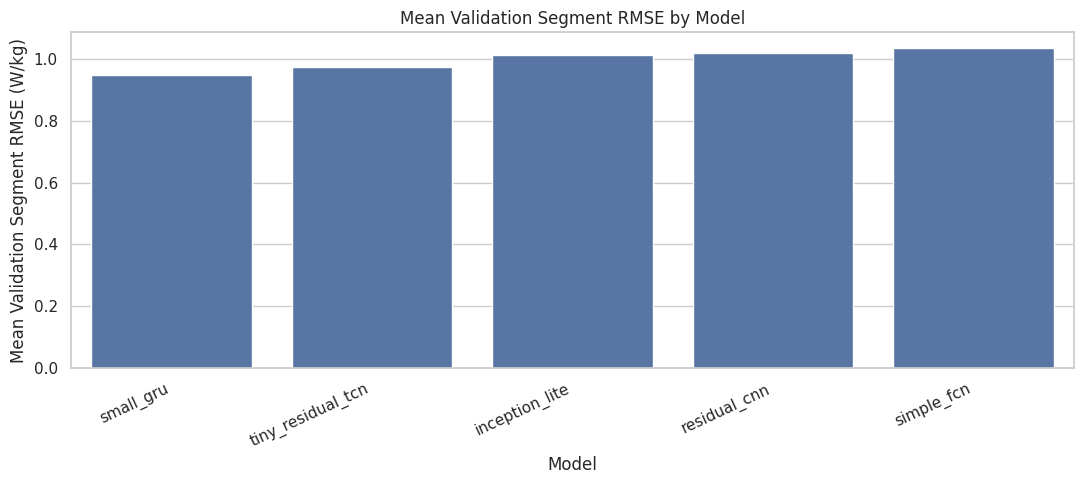

In [12]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=results, x="Model", y="Validation_Segment_RMSE_W_kg", order=ranking["Model"])
sns.stripplot(data=results, x="Model", y="Validation_Segment_RMSE_W_kg", order=ranking["Model"], color="black", alpha=0.65, size=5)
plt.title("Validation Segment RMSE Across LOSO Folds")
plt.xlabel("Model")
plt.ylabel("Validation Segment RMSE (W/kg)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_rmse_boxplot.png", dpi=160)
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=ranking, x="Model", y="Mean_Validation_Segment_RMSE_W_kg", order=ranking["Model"])
plt.title("Mean Validation Segment RMSE by Model")
plt.xlabel("Model")
plt.ylabel("Mean Validation Segment RMSE (W/kg)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_rmse_barplot.png", dpi=160)
plt.show()

## 11. Learning Curves

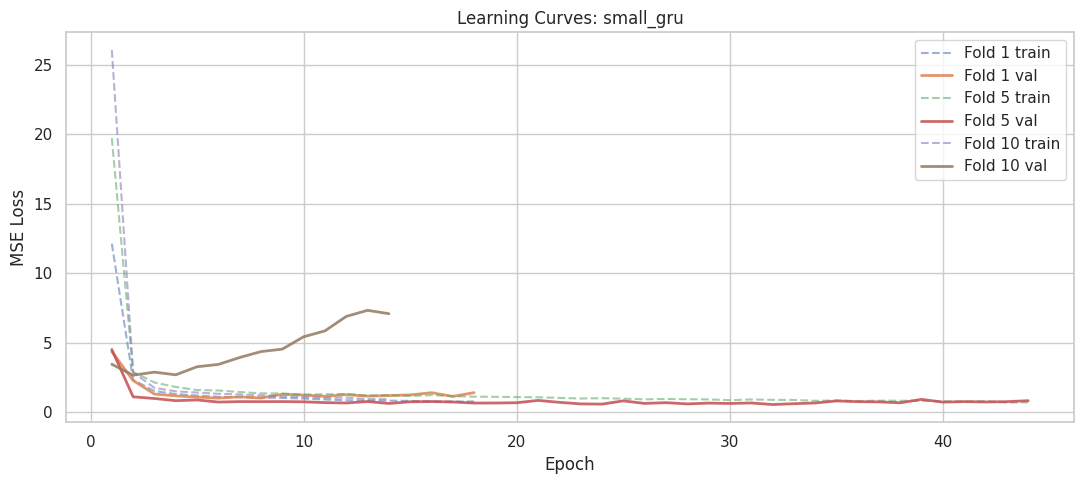

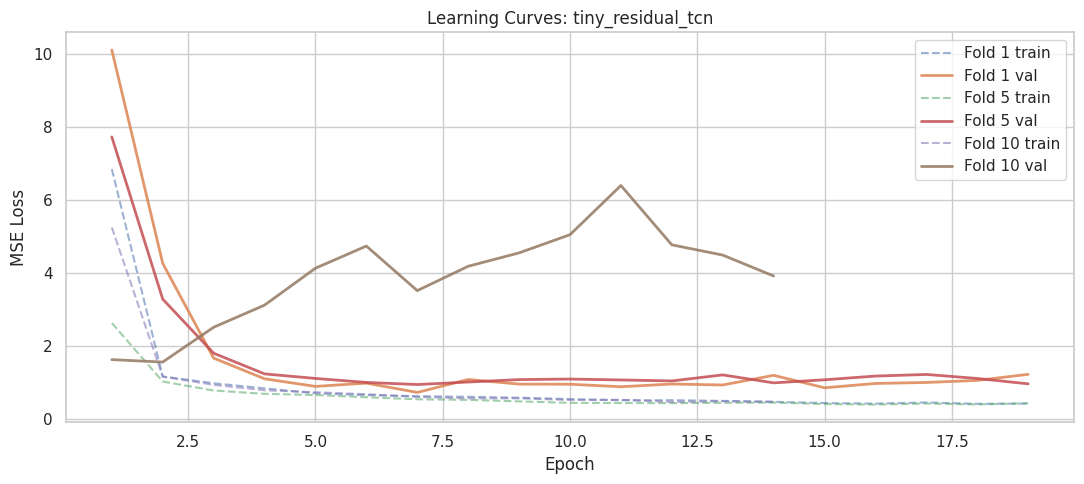

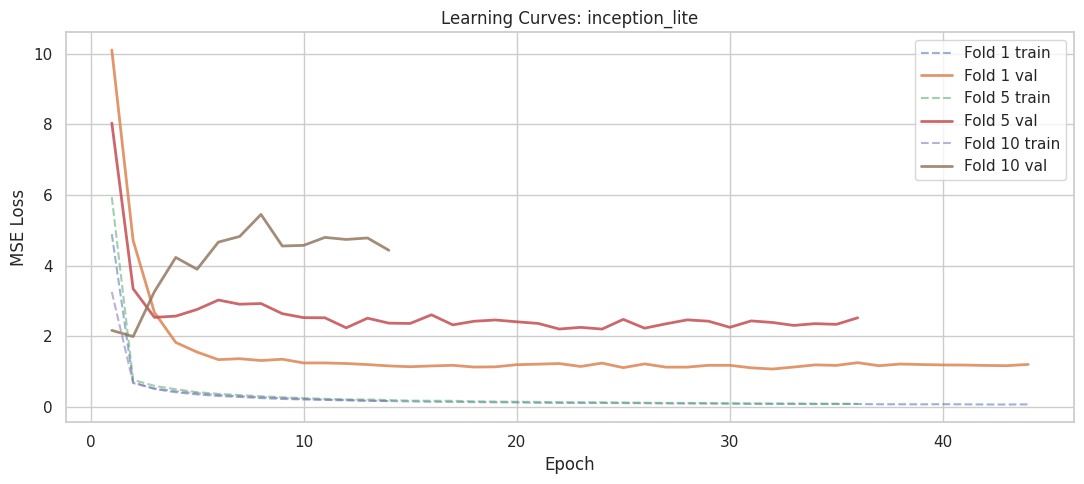

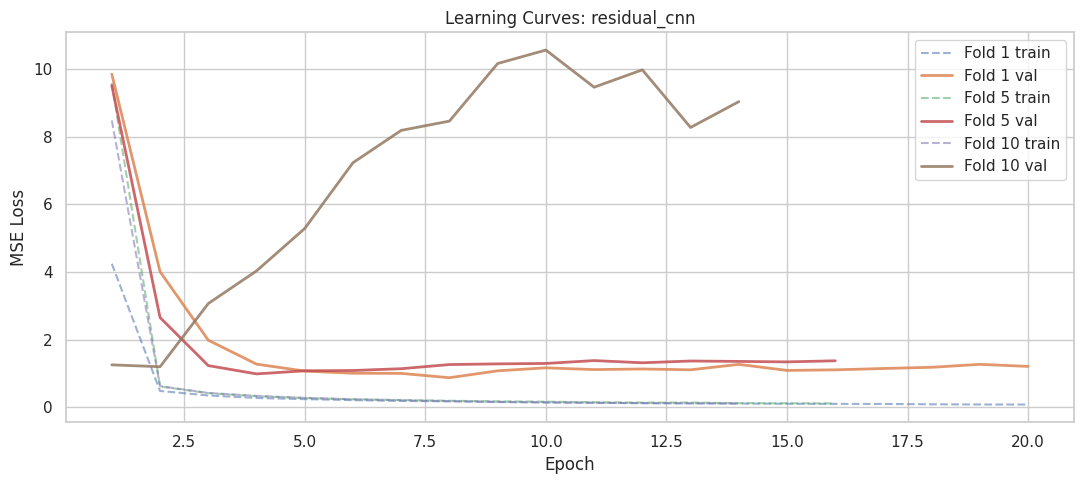

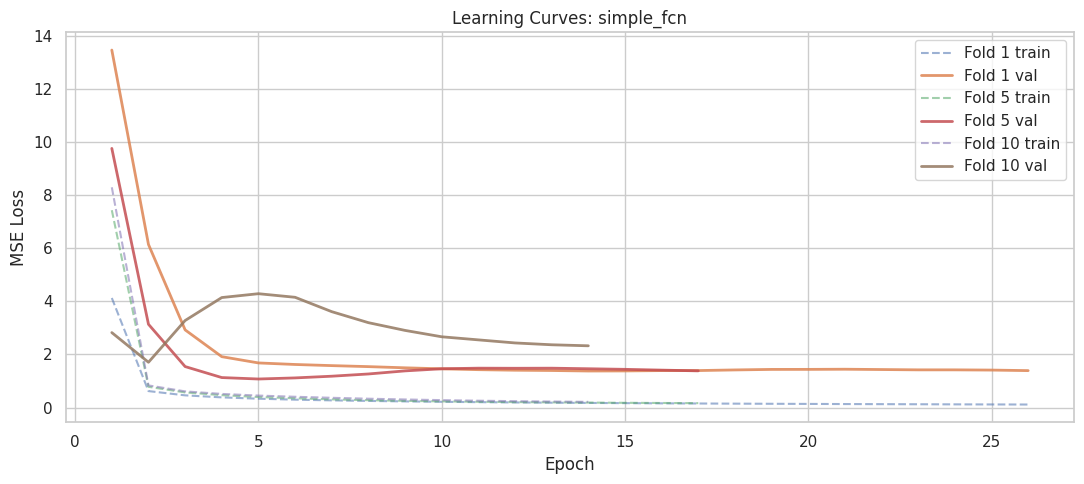

In [13]:
def plot_learning_curves_for_model(model_name, histories, folds_to_plot=None):
    """Plot training and validation loss curves for selected folds."""
    model_history = histories[histories["Model"] == model_name]
    if folds_to_plot is None:
        folds_to_plot = sorted(model_history["Fold"].unique())[:3]

    plt.figure(figsize=(11, 5))
    for fold in folds_to_plot:
        fold_history = model_history[model_history["Fold"] == fold]
        if fold_history.empty:
            continue
        plt.plot(fold_history["Epoch"], fold_history["loss"], linestyle="--", alpha=0.55, label=f"Fold {fold} train")
        plt.plot(fold_history["Epoch"], fold_history["val_loss"], linewidth=2, alpha=0.85, label=f"Fold {fold} val")

    plt.title(f"Learning Curves: {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"learning_curves_{model_name}.png", dpi=160)
    plt.show()


REPRESENTATIVE_FOLDS = [1, 5, 10]
for model_name in ranking["Model"]:
    plot_learning_curves_for_model(model_name, histories, REPRESENTATIVE_FOLDS)

## 12. Average Validation Loss Curves

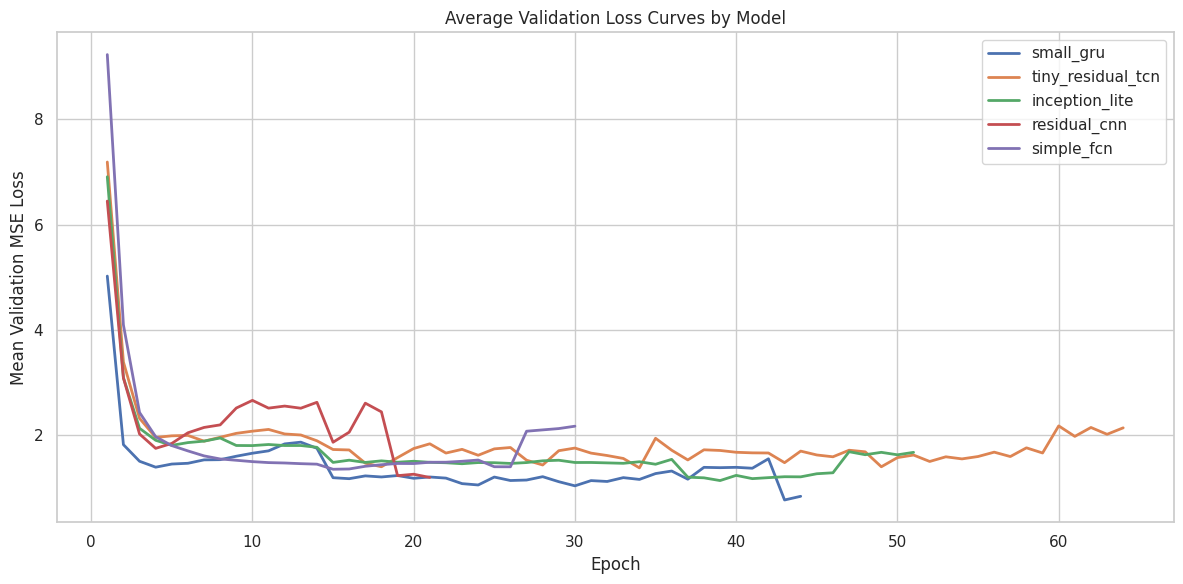

In [14]:
average_history = (
    histories.groupby(["Model", "Epoch"], as_index=False)
    .agg(
        Mean_Train_Loss=("loss", "mean"),
        Mean_Validation_Loss=("val_loss", "mean"),
        Number_of_Folds=("Fold", "nunique"),
    )
)

plt.figure(figsize=(12, 6))
for model_name in ranking["Model"]:
    model_history = average_history[average_history["Model"] == model_name]
    plt.plot(model_history["Epoch"], model_history["Mean_Validation_Loss"], linewidth=2, label=model_name)

plt.title("Average Validation Loss Curves by Model")
plt.xlabel("Epoch")
plt.ylabel("Mean Validation MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "average_validation_loss_curves.png", dpi=160)
plt.show()

## 13. Overfitting Summary

In [15]:
rows = []
for _, row in results.iterrows():
    history_row = histories[
        (histories["Model"] == row["Model"])
        & (histories["Fold"] == row["Fold"])
        & (histories["Epoch"] == row["Best Epoch"])
    ].iloc[0]

    rows.append({
        "Model": row["Model"],
        "Fold": row["Fold"],
        "Best Epoch": row["Best Epoch"],
        "Best_Train_Loss": history_row["loss"],
        "Best_Validation_Loss": history_row["val_loss"],
        "Validation_minus_Train_Loss": history_row["val_loss"] - history_row["loss"],
    })

gap_frame = pd.DataFrame(rows)
gap_summary = (
    gap_frame.groupby("Model")
    .agg(
        Mean_Best_Train_Loss=("Best_Train_Loss", "mean"),
        Mean_Best_Validation_Loss=("Best_Validation_Loss", "mean"),
        Mean_Validation_minus_Train_Loss=("Validation_minus_Train_Loss", "mean"),
        Std_Validation_minus_Train_Loss=("Validation_minus_Train_Loss", "std"),
    )
    .reset_index()
    .sort_values("Mean_Best_Validation_Loss")
)

gap_frame.to_csv(OUTPUT_DIR / "best_epoch_loss_gaps_by_fold.csv", index=False)
gap_summary.to_csv(OUTPUT_DIR / "best_epoch_loss_gap_summary.csv", index=False)
display(gap_summary)

,Model,Mean_Best_Train_Loss,Mean_Best_Validation_Loss,Mean_Validation_minus_Train_Loss,Std_Validation_minus_Train_Loss
3,small_gru,1.214615,1.125065,-0.089550,0.541458
4,tiny_residual_tcn,0.584021,1.229040,0.645019,0.733919
2,simple_fcn,0.322933,1.278586,0.955652,0.397146
1,residual_cnn,0.299419,1.298116,0.998698,0.699532
0,inception_lite,0.239180,1.301886,1.062706,0.514153


## 14. Predicted vs Actual for the Best Model

Best model by mean validation segment RMSE: small_gru


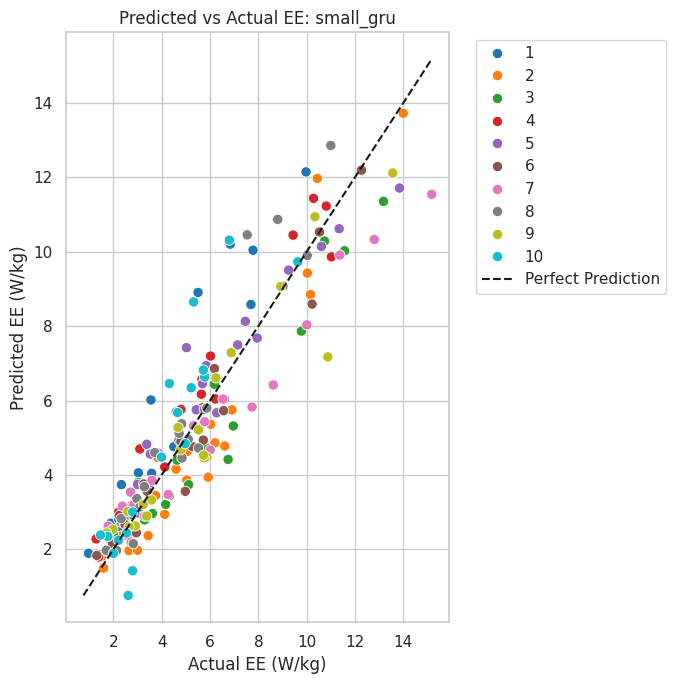

In [16]:
best_model_name = ranking.iloc[0]["Model"]
print("Best model by mean validation segment RMSE:", best_model_name)

best_test_segments = test_segment_predictions[test_segment_predictions["Model"] == best_model_name].copy()

plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_test_segments, x="Actual_W_kg", y="Predicted_W_kg", hue="Subject", palette="tab10", s=55)
min_value = min(best_test_segments["Actual_W_kg"].min(), best_test_segments["Predicted_W_kg"].min())
max_value = max(best_test_segments["Actual_W_kg"].max(), best_test_segments["Predicted_W_kg"].max())
plt.plot([min_value, max_value], [min_value, max_value], "k--", label="Perfect Prediction")
plt.title(f"Predicted vs Actual EE: {best_model_name}")
plt.xlabel("Actual EE (W/kg)")
plt.ylabel("Predicted EE (W/kg)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"predicted_vs_actual_{best_model_name}.png", dpi=160)
plt.show()

## 15. Final Selection Rule

In [17]:
SELECTION_TOLERANCE_W_KG = 0.05
best_rmse = ranking["Mean_Validation_Segment_RMSE_W_kg"].min()

candidate_pool = ranking[
    ranking["Mean_Validation_Segment_RMSE_W_kg"] <= best_rmse + SELECTION_TOLERANCE_W_KG
].copy()

candidate_pool = candidate_pool.sort_values([
    "Std_Validation_Segment_RMSE_W_kg",
    "Mean_Number_of_Parameters",
    "Mean_Validation_Segment_RMSE_W_kg",
])

selected_model_name = candidate_pool.iloc[0]["Model"]
selected_config = next(config for config in MODEL_CONFIGS if config["name"] == selected_model_name)

selection_summary = {
    "selected_model": selected_model_name,
    "selection_tolerance_W_kg": SELECTION_TOLERANCE_W_KG,
    "best_mean_validation_segment_rmse_W_kg": float(best_rmse),
    "selected_model_row": candidate_pool.iloc[0].to_dict(),
    "selected_model_config": selected_config,
}

with open(OUTPUT_DIR / "selected_model_config.json", "w") as file:
    json.dump(selection_summary, file, indent=2)

print("Selected final model:", selected_model_name)
print(json.dumps(selection_summary, indent=2))
display(candidate_pool)

Selected final model: tiny_residual_tcn
{
  "selected_model": "tiny_residual_tcn",
  "selection_tolerance_W_kg": 0.05,
  "best_mean_validation_segment_rmse_W_kg": 0.9463269841376108,
  "selected_model_row": {
    "Model": "tiny_residual_tcn",
    "Mean_Validation_Segment_RMSE_W_kg": 0.973044694734894,
    "Std_Validation_Segment_RMSE_W_kg": 0.30470366863297765,
    "Mean_Validation_Segment_MAE_W_kg": 0.7493257462978363,
    "Mean_Validation_Segment_R2_W_kg": 0.8766653537750244,
    "Mean_Test_Segment_RMSE_W_kg": 1.198183821925556,
    "Std_Test_Segment_RMSE_W_kg": 0.2665368937519604,
    "Mean_Best_Epoch": 18.2,
    "Mean_Trained_Epochs": 30.2,
    "Mean_Training_Time_Seconds": 40.6093047618866,
    "Mean_Number_of_Parameters": 19489.0
  },
  "selected_model_config": {
    "name": "tiny_residual_tcn",
    "reason": "TCN uses residual blocks and dilated convolutions for temporal context.",
    "params": {
      "filters": 32,
      "kernel_size": 3,
      "dropout": 0.1,
      "learning

,Model,Mean_Validation_Segment_RMSE_W_kg,Std_Validation_Segment_RMSE_W_kg,Mean_Validation_Segment_MAE_W_kg,Mean_Validation_Segment_R2_W_kg,Mean_Test_Segment_RMSE_W_kg,Std_Test_Segment_RMSE_W_kg,Mean_Best_Epoch,Mean_Trained_Epochs,Mean_Training_Time_Seconds,Mean_Number_of_Parameters
4,tiny_residual_tcn,0.973045,0.304704,0.749326,0.876665,1.198184,0.266537,18.2,30.2,40.609305,19489.0
3,small_gru,0.946327,0.307903,0.761263,0.867945,1.113735,0.305777,16.1,28.1,18.643040,5889.0
